# AI4I 2020: анализ данных и прогноз отказа оборудования

Цель — предсказать `Machine failure` по пяти датчикам и категории `Type`, сравнив линейную модель, Random Forest и CatBoost.

In [1]:
import os
import sys
from contextlib import redirect_stderr, redirect_stdout
from io import StringIO
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run notebook from the repository root or notebooks directory")
sys.path.insert(0, str(ROOT))
os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"

In [2]:
import mlflow
import pandas as pd
from IPython.display import Image, display

from ml.train import (
    DATA_PATH,
    EXPERIMENT_NAME,
    MODEL_ALIAS,
    MODEL_NAME,
    evaluate_final,
    load_data,
    log_eda,
    register_candidates,
    select_candidates,
    split_data,
    train_candidates,
)

mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI", "http://127.0.0.1:5050"))
mlflow.set_experiment(EXPERIMENT_NAME)

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1791484491399, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1791484491399, lifecycle_stage='active', name='predictiveguard-ai4i', tags={}, trace_location=None, workspace='default'>

## Данные

Идентификаторы `UDI`, `Product ID` и признаки уже произошедшего отказа `TWF/HDF/PWF/OSF/RNF` исключены. Разбиение train/validation/test — 60/20/20%, стратификация по цели, seed=42.

In [3]:
raw, frame = load_data(DATA_PATH)
splits = split_data(frame)
print(f"Исходный датасет: {len(raw)} строк, {int(raw['Machine failure'].sum())} отказов.")
display(frame.head())
display(
    pd.DataFrame(
        {
            name: {
                "rows": len(part),
                "failures": int(part.failure.sum()),
                "failure_rate": part.failure.mean(),
            }
            for name, part in splits.items()
        }
    ).T
)

Исходный датасет: 10000 строк, 339 отказов.


,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,failure
UDI,,,,,,,
1,M,298.1,308.6,1551.0,42.8,0.0,0
2,L,298.2,308.7,1408.0,46.3,3.0,0
3,L,298.1,308.5,1498.0,49.4,5.0,0
4,L,298.2,308.6,1433.0,39.5,7.0,0
5,L,298.2,308.7,1408.0,40.0,9.0,0


,rows,failures,failure_rate
training,6000.0,203.0,0.033833
validation,2000.0,68.0,0.034000
test,2000.0,68.0,0.034000


## Анализ обучающей выборки

In [4]:
train = splits["training"]
display(train.describe(include="all").T)
print("Пропуски:", int(train.isna().sum().sum()))
print("Дубликаты строк признаков и цели:", int(train.duplicated().sum()))
with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
    eda_run = log_eda(splits, DATA_PATH)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
type,6000,3,L,3624,NaN,NaN,NaN,NaN,NaN,NaN,NaN
air_temperature_k,6000.0,NaN,NaN,NaN,300.007133,1.996217,295.3,298.3,300.1,301.5,304.5
process_temperature_k,6000.0,NaN,NaN,NaN,310.002433,1.47565,305.7,308.8,310.1,311.0,313.8
rotational_speed_rpm,6000.0,NaN,NaN,NaN,1539.746833,179.168871,1168.0,1422.0,1504.0,1615.0,2861.0
torque_nm,6000.0,NaN,NaN,NaN,39.951783,9.99515,4.6,33.1,40.0,46.8,76.2
tool_wear_min,6000.0,NaN,NaN,NaN,107.101333,63.641243,0.0,52.0,106.0,162.0,253.0
failure,6000.0,NaN,NaN,NaN,0.033833,0.180815,0.0,0.0,0.0,0.0,1.0


Пропуски: 0
Дубликаты строк признаков и цели: 0


### Классы и категория оборудования

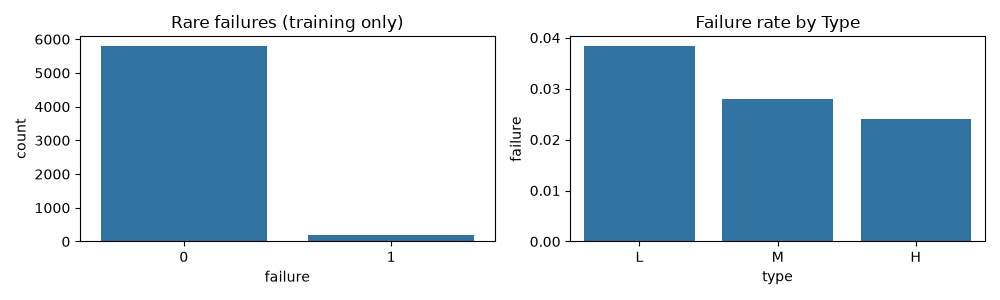

In [5]:
with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
    image_path = mlflow.artifacts.download_artifacts(
        run_id=eda_run, artifact_path="eda/target_and_type.png"
    )
display(Image(filename=image_path))

Отказы составляют около 3,4% наблюдений: accuracy недостаточна для сравнения моделей. Частота отказов различается между категориями оборудования, поэтому Type включён в признаки.

### Корреляции

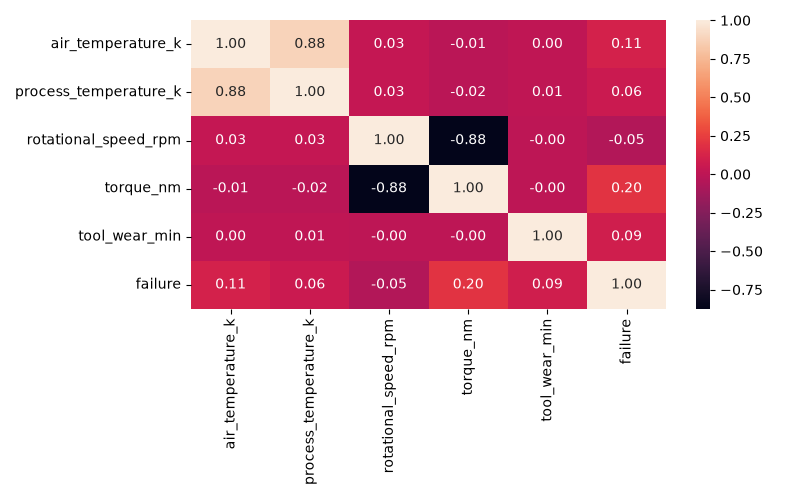

In [6]:
with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
    image_path = mlflow.artifacts.download_artifacts(
        run_id=eda_run, artifact_path="eda/correlations.png"
    )
display(Image(filename=image_path))

Температуры воздуха и процесса тесно связаны. Скорость вращения и крутящий момент имеют обратную связь. Линейные корреляции не описывают все механизмы отказа — проверим также древесные модели.

### Распределения датчиков

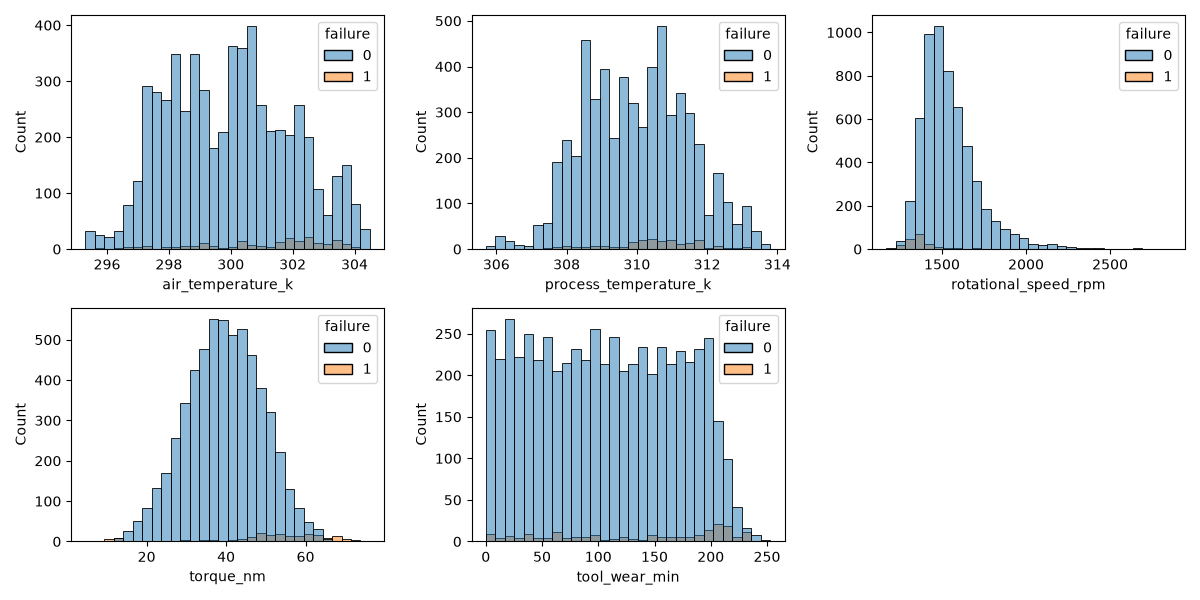

In [7]:
with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
    image_path = mlflow.artifacts.download_artifacts(
        run_id=eda_run, artifact_path="eda/distributions.png"
    )
display(Image(filename=image_path))

Распределения классов перекрываются: одного датчика недостаточно для надёжного разделения. Проверяем сочетания признаков; редкий класс учитываем через balanced weights.

## Обучение и сравнение

Baseline — Dummy prior. Logistic Regression использует median imputation, scaling и one-hot Type; преобразования обучаются только на train. Random Forest: 250 деревьев, depth=12. CatBoost: 500 итераций, depth=6, learning rate=0.05, категориальный Type без one-hot.

Основная метрика — validation Average Precision. Порог максимизирует validation F1. Допуск: AP выше baseline, precision ≥ 0.2, recall ≥ 0.5 и совпадение предсказаний после сохранения и загрузки.

In [8]:
with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
    results = train_candidates(splits, DATA_PATH)
comparison = pd.DataFrame(results).sort_values("average_precision", ascending=False)
display(
    comparison[
        [
            "name",
            "average_precision",
            "roc_auc",
            "precision",
            "recall",
            "f1",
            "accuracy",
            "threshold",
            "passed",
        ]
    ]
)
selected = select_candidates(results)
best = selected[0]
print("Выбрана модель:", best["name"])

,name,average_precision,roc_auc,precision,recall,f1,accuracy,threshold,passed
3,04-catboost,0.729672,0.974904,0.698413,0.647059,0.671756,0.9785,0.647263,True
2,03-random-forest,0.598900,0.962520,0.600000,0.661765,0.629371,0.9735,0.615318,True
1,02-logistic-balanced,0.368017,0.878821,0.294574,0.558824,0.385787,0.9395,0.775720,True
0,01-dummy-prior,0.034000,0.500000,0.000000,0.000000,0.000000,0.9660,0.500000,False


Выбрана модель: 04-catboost


### Диагностика выбранной модели на validation

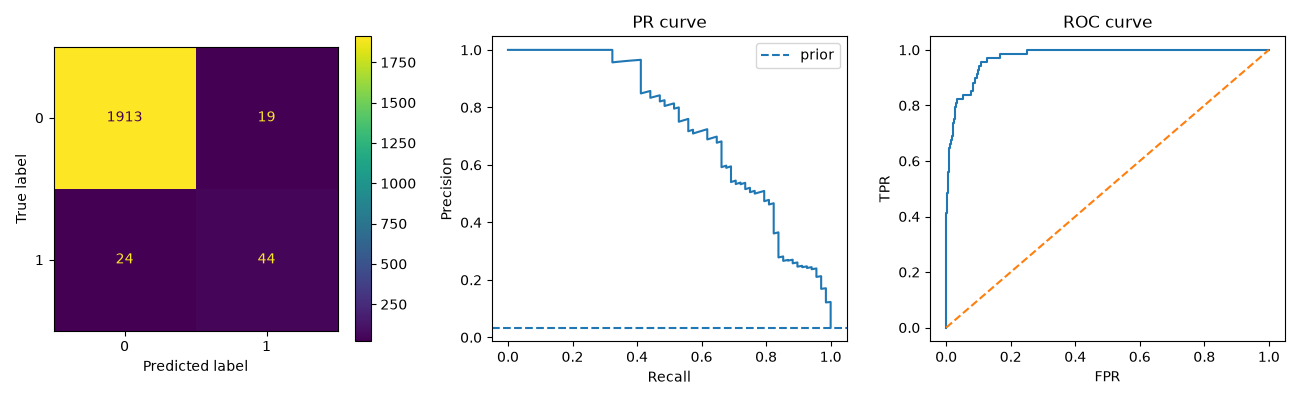

In [9]:
with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
    image_path = mlflow.artifacts.download_artifacts(
        run_id=best["run_id"], artifact_path="validation/diagnostics.png"
    )
display(Image(filename=image_path))

Confusion matrix показывает пропущенные отказы и ложные тревоги при выбранном пороге. PR-кривая отражает компромисс precision/recall при редком положительном классе; ROC-AUC используется как вспомогательная метрика.

## Итоговая оценка

Модель и порог зафиксированы по validation. Test оценивается один раз и не влияет на выбор.

In [10]:
with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
    test_metrics = evaluate_final(best, splits, DATA_PATH)
display(pd.Series(test_metrics, name="test"))

average_precision    0.788606
roc_auc              0.967894
f1                   0.748201
precision            0.732394
recall               0.764706
accuracy             0.982500
Name: test, dtype: float64

## Сохранение модели

В MLflow сохраняются данные, параметры, метрики и артефакты. Две выбранные модели регистрируются, лучшей назначается alias `champion`.

In [11]:
with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
    versions = register_candidates(selected, MODEL_NAME, MODEL_ALIAS)
print(f"Сохранена {best['name']}, версия {versions[-1].version}.")

Сохранена 04-catboost, версия 4.


## Выводы

In [12]:
baseline = next(item for item in results if "dummy" in item["name"])
print(
    f"{best['name']}: validation AP={best['average_precision']:.4f}; "
    f"baseline AP={baseline['average_precision']:.4f}."
)
print(
    f"Порог={best['threshold']:.4f}; test AP={test_metrics['average_precision']:.4f}, "
    f"precision={test_metrics['precision']:.4f}, recall={test_metrics['recall']:.4f}."
)

04-catboost: validation AP=0.7297; baseline AP=0.0340.
Порог=0.6473; test AP=0.7886, precision=0.7324, recall=0.7647.


AI4I — синтетические данные. Случайное стратифицированное разбиение оценивает качество при сходном распределении; перенос на реальное оборудование требует временной или групповой проверки и учёта стоимости ошибок.